# 02 · Baselines estadísticos

Antes de entrenar un modelo de ML hay que saber **qué tan lejos llega lo simple**. Cinco
baselines con `statsforecast`, evaluados con backtesting en 3 ventanas de 28 días
(2016-02-29 → 2016-05-22), reentrenando en cada corte:

| Modelo | Idea |
| --- | --- |
| Naive | Mañana = último valor observado |
| SeasonalNaive | Mañana = mismo día de la semana pasada |
| MediaMovil28 | Promedio de los últimos 28 días |
| AutoETS | Suavizamiento exponencial con selección automática |
| AutoARIMA | ARIMA estacional con selección automática |

Los resultados salen de `make baselines evaluate`; este notebook solo los lee.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.models.baselines import BASELINE_MODELS
from src.utils import plotting as pl

pl.use_style()


def baselines_eval(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    return df[(df["split"] == "eval") & df["model"].isin(BASELINE_MODELS)]


wr = baselines_eval(config.METRICS_WRMSSE)
seg = baselines_eval(config.METRICS_SEGMENT)

## 1. WRMSSE por ventana

El WRMSSE es la métrica de la competencia M5: error cuadrático escalado por el de un naive
de un paso, ponderado por ingreso y promediado en tres niveles de agregación
(total → departamento → SKU). Un valor de 1 equivale al naive de un paso *dentro de la
muestra*; menor es mejor. Al usar la jerarquía de este subconjunto, no es comparable con el
leaderboard de Kaggle, pero sí entre los modelos del proyecto.

In [2]:
by_window = wr[wr["level"] == "WRMSSE"].pivot(index="cutoff", columns="model", values="value")
by_window.index = by_window.index.strftime("%Y-%m-%d")
by_window.loc["promedio"] = by_window.mean()
order = by_window.loc["promedio"].sort_values().index
by_window[order].round(3)

model,AutoETS,SeasonalNaive,AutoARIMA,MediaMovil28,Naive
cutoff,,,,,
2016-02-28,0.638,0.779,0.890,0.989,1.700
2016-03-27,0.578,0.879,0.870,0.974,1.263
2016-04-24,0.609,0.699,0.845,0.971,1.479
promedio,0.608,0.785,0.869,0.978,1.481


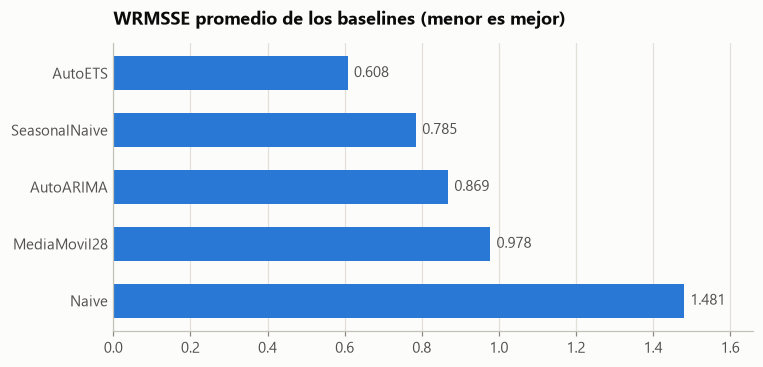

level,total,dept,sku,WRMSSE
model,,,,
AutoETS,0.466,0.551,0.807,0.608
SeasonalNaive,0.596,0.729,1.031,0.785
AutoARIMA,0.877,0.908,0.821,0.869
MediaMovil28,1.045,1.057,0.832,0.978
Naive,1.579,1.687,1.176,1.481


In [3]:
levels = wr.groupby(["level", "model"])["value"].mean().unstack("level")
levels = levels.loc[order, ["total", "dept", "sku", "WRMSSE"]]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.barh(levels.index[::-1], levels["WRMSSE"][::-1], height=0.6, color=pl.BLUE)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in levels["WRMSSE"][::-1]], padding=4,
             color=pl.INK_SECONDARY)
ax.set_title("WRMSSE promedio de los baselines (menor es mejor)")
ax.set_xlim(0, levels["WRMSSE"].max() * 1.12)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
pl.save(fig, "09_wrmsse_baselines")
plt.show()

levels.round(3)

**AutoETS es el baseline a vencer**, con un WRMSSE claramente menor que SeasonalNaive. La
tabla por nivel explica el orden:

- **SeasonalNaive** acierta el patrón semanal en los niveles agregados, pero a nivel SKU
  copia el ruido de la semana anterior.
- **MediaMovil28** hace lo contrario: es un buen estimador del *nivel* de cada SKU, pero es
  plano y no ve la semana, así que falla en total y departamento.
- **AutoETS** combina ambas cosas: nivel suavizado + estacionalidad semanal.
- **AutoARIMA** queda por detrás de ETS en los niveles agregados, donde pesa el patrón semanal.

## 2. Otra métrica, otra historia: WAPE y sesgo

El WAPE (error absoluto / demanda total) se calcula solo a nivel SKU-día, que es el nivel
al que se decide el inventario.

In [4]:
total = seg[seg["grouping"] == "total"].set_index("model").loc[order, ["mae", "wape", "bias", "rmsse"]]
total.round(3)

,mae,wape,bias,rmsse
model,,,,
AutoETS,1.436,0.667,-0.030,0.734
SeasonalNaive,1.720,0.799,-0.042,0.946
AutoARIMA,1.459,0.678,-0.022,0.739
MediaMovil28,1.471,0.683,-0.040,0.742
Naive,2.033,0.944,0.234,0.986


A nivel SKU-día, MediaMovil28 prácticamente empata con AutoETS y AutoARIMA: en demanda
intermitente, **un buen promedio es difícil de superar**. Todos los baselines razonables
sub-pronostican un poco (sesgo negativo), consistente con una demanda que viene creciendo.

Conclusión para el resto del proyecto: la vara no es SeasonalNaive sino **AutoETS en
WRMSSE y MediaMovil28 en WAPE**.

## 3. Mejor baseline por segmento ABC/XYZ

In [5]:
by_seg = seg[seg["grouping"] == "segment"].pivot(index="group", columns="model", values="wape")
summary = pd.DataFrame(
    {
        "n_skus": seg[seg["grouping"] == "segment"].groupby("group")["n_skus"].first(),
        "mejor_baseline": by_seg.idxmin(axis=1),
        "wape_mejor": by_seg.min(axis=1),
        "wape_seasonal_naive": by_seg["SeasonalNaive"],
    }
)
summary.round(3)

,n_skus,mejor_baseline,wape_mejor,wape_seasonal_naive
group,,,,
AX,306,AutoETS,0.516,0.653
AY,245,AutoETS,0.611,0.712
AZ,52,AutoARIMA,0.681,0.746
BX,85,AutoETS,0.855,1.047
BY,302,AutoETS,0.949,1.132
BZ,71,AutoETS,0.815,0.944
CX,10,AutoETS,1.023,1.272
CY,168,AutoETS,1.134,1.305
CZ,190,AutoARIMA,0.959,1.104


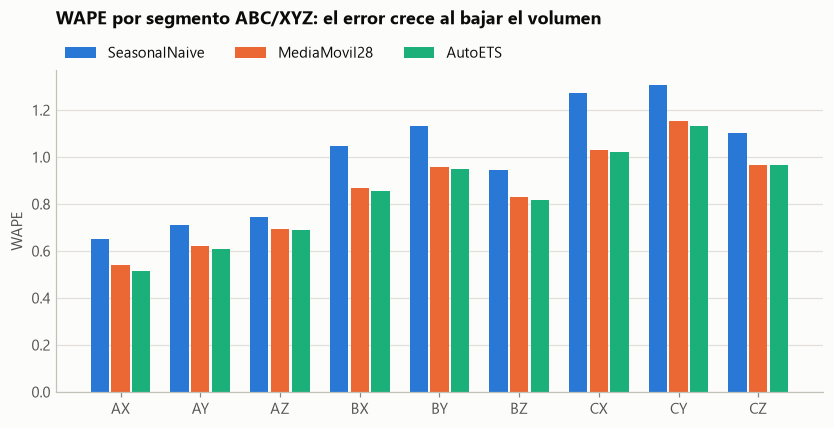

In [6]:
ref = by_seg[["SeasonalNaive", "MediaMovil28", "AutoETS"]]

fig, ax = plt.subplots(figsize=(9, 3.8))
width = 0.26
for i, (model, color) in enumerate(zip(ref.columns, pl.CATEGORICAL, strict=False)):
    ax.bar([x + (i - 1) * width for x in range(len(ref))], ref[model], width=width - 0.03,
           color=color, label=model)
ax.set_xticks(range(len(ref)), ref.index)
ax.set_title("WAPE por segmento ABC/XYZ: el error crece al bajar el volumen", pad=30)
ax.set_ylabel("WAPE")
ax.set_ylim(0)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=3, borderaxespad=0.2)
pl.save(fig, "10_wape_baselines_segmento")
plt.show()

- El error relativo depende mucho más del **segmento** que del modelo: en AX el WAPE ronda
  0.5 y en la clase C ronda o supera 1 (el error es tan grande como la demanda).
- AutoETS, AutoARIMA y la media móvil quedan a menos de 0.03 de WAPE entre sí en todos los
  segmentos: a nivel SKU no hay mucha señal que un modelo univariado más complejo pueda
  explotar. El que sí se despega, para mal, es SeasonalNaive.
- La mayor ventaja de AutoETS sobre la media móvil está en AX (0.516 vs 0.541), que es
  también donde está casi la mitad del ingreso. Ese es el terreno donde el modelo de ML
  tiene que ganar.

## 4. Por patrón de demanda

In [7]:
by_pattern = seg[seg["grouping"] == "pattern"].pivot(index="group", columns="model", values="wape")
by_pattern[order].round(3)

model,AutoETS,SeasonalNaive,AutoARIMA,MediaMovil28,Naive
group,,,,,
errática,0.657,0.774,0.638,0.635,0.815
intermitente,0.789,0.931,0.800,0.801,1.067
irregular,0.936,1.113,0.951,0.953,1.315
suave,0.465,0.575,0.478,0.491,0.728


## Resumen

| Hallazgo | Implicación |
| --- | --- |
| AutoETS es el mejor baseline en WRMSSE | Es la referencia real para el modelo de ML |
| En WAPE a nivel SKU, la media móvil empata con ETS/ARIMA | En intermitentes, lo simple es competitivo |
| El error depende más del segmento que del modelo | Reportar siempre por ABC/XYZ, no solo el total |
| AutoARIMA no mejora a AutoETS | No se usa para la política de inventario |